<a href="https://colab.research.google.com/github/h186487/DAT158MLSopp/blob/main/notebooks/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01: EDA and cleaning


Kort intro: hva notebooken gjør, hvilket datasett (UCI Mushroom), hvem som har laget den (A).

## 1. Hent data

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

m = fetch_ucirepo(id=73)
X, y = m.data.features, m.data.targets


## 2. Første oversikt

In [ ]:
print(X.shape)
print(list(X.columns))
print(y.value_counts(normalize=True))
X.head()

(8124, 22)
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
poisonous
e            0.517971
p            0.482029
Name: proportion, dtype: float64


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


Datasettet har 5 rader og x features. Klassene er (nesten) balansert: ca. 48% giftige.

## 3. Datakvalitet

In [ ]:
print("NaN per kolonne:")
print(X.isna().sum()[lambda s: s > 0])

print("\n'?' per kolonne:")
print((X == "?").sum()[lambda s: s > 0])

print("\nKolonner med færrest unike verdier:")
print(X.nunique().sort_values().head())

print("\nAntall duplikater:", X.duplicated().sum())

NaN per kolonne:
stalk-root    2480
dtype: int64

'?' per kolonne:
Series([], dtype: int64)

Kolonner med færrest unike verdier:
veil-type       1
bruises         2
gill-spacing    2
gill-size       2
stalk-shape     2
dtype: int64

Antall duplikater: 0


Notat: hva du fant, og hva du bestemte deg for å gjøre med det.
- Manglende verdier: kolonne X har N (kodet som `?` / NaN).
- Konstante kolonner: Y (bare én verdi, droppes).
- Duplikater: N rader. Beslutning: ... (begrunn).

## 4. Utforsking (EDA)

<Axes: title={'center': 'Andel giftige per odor'}, ylabel='odor'>

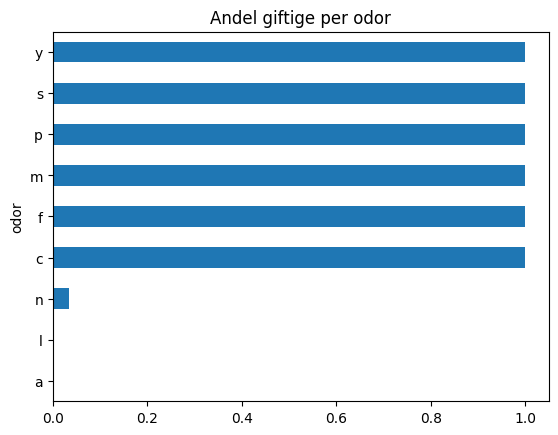

In [ ]:
import matplotlib.pyplot as plt

y_bin = (y.iloc[:, 0] == "p").astype(int)   # 1 = giftig, 0 = spiselig

y_bin.value_counts().rename({0: "spiselig", 1: "giftig"}).plot.bar(title="Klassefordeling")
plt.ylabel("Antall")
plt.show()

In [ ]:
df = X.copy()
df["poisonous"] = y_bin

for col in ["odor", "spore-print-color", "gill-size"]:   # sjekk at navnene finnes i X.columns
    df.groupby(col)["poisonous"].mean().sort_values().plot.barh(title=f"Andel giftige per {col}")
    plt.xlabel("Andel giftige")
    plt.show()

Notat: hva hver figur viser.
Figurene viser at `odor` skiller klassene veldig godt: ... (beskriv hva du ser).

## 5. Cleaning

In [ ]:
X_clean = X.replace("?", "unknown").fillna("unknown")

# dropp konstante kolonner
const_cols = [c for c in X_clean.columns if X_clean[c].nunique() <= 1]
print("Droppes:", const_cols)
X_clean = X_clean.drop(columns=const_cols)

# duplikater: kommenter inn hvis dere bestemmer dere for å fjerne dem
# mask = ~X_clean.duplicated()
# X_clean, y_bin = X_clean[mask], y_bin[mask]

print(X_clean.shape)
X_clean.head()

Notat: hvorfor du valgte dette.
- `?` og NaN erstattet med `"unknown"` (samme verdi som "Vet ikke" i appen).
- Konstante kolonner droppet: ...
- Duplikater: (fjernet / beholdt, med begrunnelse).

## 6. Train/test-split

In [ ]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X_clean, y_bin, test_size=0.2, stratify=y_bin, random_state=42)

Xtr.assign(poisonous=ytr).to_csv("train.csv", index=False)
Xte.assign(poisonous=yte).to_csv("test.csv", index=False)

print(Xtr.shape, Xte.shape)
print(ytr.mean(), yte.mean())

Notat: 80/20, stratified, random_state=42.